Signal to Noise Ratio can be defined as the reciprocal of the coefficient of variation, also its square.
To calculate the reciprocal mean/std

Should try this on baseline corrected spectra as well

**Packages and Functions**

In [33]:
library(plotly);
library(tidyverse); # for data manipulation and visualization
library(patchwork); # for combining plots
library(here); # for file path management
library(arrow); # for saving dataframes
library(ptw);
library(pracma);
library(ggforce);
library(purrr);

split_by_species <- function(df, species_col = "species") {
  split(df, df[[species_col]])
}


plot_by_time <- function(df, title_input = "Title") {
  df |> 
    filter(instrument == "DAD") |>
    mutate(sample_id = paste(enzyme, sample, time_point, species, sep = "_")) |>
    ggplot(
      aes(
        x = time,
        y = intensity,
        color = time_point,
        group = sample_id,
    )
  ) +
  geom_line() +
  labs(
    title = title_input,
    x = "Retention Time",
    y = "Intensity (au)"
  )+
  theme(
    plot.title = element_text(face = "bold"), 
    axis.title.x = element_text(face = "bold"),         
    axis.title.y = element_text(face = "bold"))
  
}


wide_to_long <- function(df) {
  df |> 
    pivot_longer(
      cols = where(is.numeric),
      names_to = "time",
      values_to = "intensity"
    )
}

long_to_wide <- function(df) {
  df |>
    pivot_wider(
      id_cols = where(~ !is.numeric(.x)),
      names_from = time,
      values_from = intensity
    )
}


##############-----------------------Scale----------------------------#######################
riemann_integrate <- function(df, rt1, rt2){
  df <- df |>
    mutate(time = as.numeric(time)) |> 
    select(where(is.numeric))
  
  df |>
  filter(time >= rt1, time <= rt2) |>
  arrange(time) |>
  mutate(
    dt = time - lag(time),
    intensity_mid = (intensity + lag(intensity)) / 2,
    area = dt * intensity_mid
  ) |> 
  filter(!is.na(area)) |> 
  summarise(area = sum(area)) |>
  pull(area)
}

normalize <- function(df, t_min = .7, t_max = 10, from_wide = FALSE){
  if (from_wide) {
    df <- df |> wide_to_long()
  }

  df |>
    mutate(time = as.numeric(time)) |>
    mutate(
      total_area = riemann_integrate(cur_data(), t_min, t_max),
      intensity = intensity / total_area
    ) |>
    ungroup() |>
    select(-total_area)
}

normalize_byspecies <- function(df, t_min = .7, t_max = 10, from_wide = FALSE){
  if (from_wide) {
    df <- df |> wide_to_long()
  }

  df |>
    mutate(time = as.numeric(time)) |>
    group_by(species, sample, time_point) |>
    mutate(
      total_area = riemann_integrate(cur_data(), t_min, t_max),
      intensity = intensity / total_area
    ) |>
    ungroup() |>
    select(-total_area)
}

##############-----------------------Baseline-------------------------#######################
correct_baseline <- function(df, l = 1*10^9, maxit = 25, meta_in = TRUE) {
  # keep metadata
  if (meta_in) {
  meta <- df |> select(where(~ !is.numeric(.)))
  }

  # apply baseline correction only to numeric columns
  numeric_df <- df |> select(where(is.numeric))
  numeric_corrected <- baseline.corr(numeric_df, lambda = l, p = 0.001, eps = 1e-8, maxit = maxit)
  
  if (meta_in) {
  combined <- bind_cols(meta, numeric_corrected)
  return(combined)
  }
  return(numeric_corrected)
}
##############------------------------PCA-------------------------#######################
pca <- function(df, num_comp = 10, center_in = TRUE, scale_in = TRUE, scale_na = FALSE) {

  df <- df |> 
    mutate(time_point = factor(time_point, levels = c("0", "2", "5", "15", "30")))
  
  metadata <- df |> 
    select(!where(is.numeric))

  if (scale_na) {
  dataPCA <- df |>
    select(where(is.numeric)) |>
    mutate(across(
      everything(),
      ~ ifelse(is.na(.), min(., na.rm = TRUE) / 2, .)
    ))
  } else {
  dataPCA <- df |>
    select(where(is.numeric))
  }

  pca_res <- prcomp(dataPCA, center = center_in, scale. = scale_in)

  scores <- as.data.frame(pca_res$x[, 1:num_comp, drop = FALSE])
  scores <- bind_cols(metadata, scores)
  loadings <- as.data.frame(pca_res$rotation[, 1:num_comp, drop = FALSE])
  variance <- data.frame(variance = (pca_res$sdev^2) / sum(pca_res$sdev^2))

  list(
    df = df,
    scores = scores,
    loadings = loadings,
    variance = variance
  )
}

plot_scores <- function(scores, PC_first, PC_second, title_in = "", file_path = NULL) {

  PC_first  <- rlang::enquo(PC_first)
  PC_second <- rlang::enquo(PC_second)

  circle_df <- scores |> 
    group_by(species) |> 
    summarize(
      x0 = mean(!!PC_first, na.rm = TRUE),
      y0 = mean(!!PC_second, na.rm = TRUE),
      r = max(
        sqrt((!!PC_first - x0)^2 + (!!PC_second - y0)^2),
        na.rm = TRUE
      ),
      .groups = "drop"
    )

  label_positions <- circle_df |> 
    mutate(
      dx = x0 / sqrt(x0^2 + y0^2),
      dy = y0 / sqrt(x0^2 + y0^2),
      x = x0 + dx * (r * 1.08),
      y = y0 + dy * (r * 1.08)
    )

  p <- ggplot(scores, aes(x = !!PC_first, y = !!PC_second)) +

    geom_point(
      aes(color = time_point, shape = species),
      size = 3
    ) +

    # geom_label(
    #   data = label_positions,
    #   aes(x = x, y = y, label = species),
    #   inherit.aes = FALSE,
    #   fill = "white",
    #   color = "black",
    #   size = 3,
    #   label.size = 0.25
    # ) +

    scale_color_viridis_d(
      option = "viridis",
      name = "Incubation Time"
    ) +

    labs(
      title = title_in,
      subtitle = "Colored by incubation time; species-level dispersion shown",
      x = rlang::as_label(PC_first),
      y = rlang::as_label(PC_second)
    ) +

    coord_equal() +
    theme_minimal()

  if (!missing(file_path) && !is.null(file_path)) {
  ggsave(
    filename = file_path,
    plot = last_plot(),
    dpi = 300,
    width = 8,
    height = 6,
    units = "in"
  )
  }
  return(p)
}

plot_loadings <- function(df, PC) {
  PC  <- rlang::enquo(PC)

  ggplot(df, aes(x = time, y = !!PC))+ 
  geom_line()+
  labs(title = "PCA Loadings Plot",
       x = "Time",
       y = rlang::as_label(PC)) +
  theme_minimal()
}

plot_scree <- function(df){
  df <- df |> 
  mutate(
    PC = factor(
      paste0("PC", row_number()),
      levels = paste0("PC", row_number())
    )
  )

  df_new <- df |> 
  mutate(cumulative = cumsum(variance)) |> 
  slice(1:10)
  
  ggplot(df_new, aes(x = PC, y = variance, group = 1)) +
  geom_line(linewidth = .7) +
  geom_point(size = 1) +
  geom_text(data = df_new |> slice(1:4),
            inherit.aes = FALSE,
            aes(x = PC, y = variance, label = paste0(round(cumulative*100), "%")), 
            vjust = -0.5, hjust = -.4, size = 3) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title = "Scree Plot of Principal Components",
    x = "Principal Component",
    y = "Proportion of Variance Explained",
    caption = "Percentages indicate cumulative variance explained"
  ) +
  theme_minimal()
}

##############------------------------PTW-------------------------#######################


ptw_function <- function(df) {
  meta <- df |> 
    select(time_point, species, sample, enzyme, instrument)

  Num <- df |> select(where(is.numeric))

  reference_num <- Num[1, ]
  samples_num   <- Num[2:15, ]

  reference_meta <- meta[1, ]
  samples_meta   <- meta[2:15, ]

  res <- ptw(reference_num, samples_num, warp.type = "individual")

  warped_df <- as.data.frame(res$warped.sample)
  reference_df <- as.data.frame(res$reference)

  colnames(warped_df) <- colnames(reference_df)

  warped_full <- bind_cols(samples_meta, warped_df)
  reference_full <- bind_cols(reference_meta, reference_df)

  final_df <- bind_rows(reference_full, warped_full)

  return(final_df)
}


**Import Dataframes**

In [34]:
combinedLong <- read_parquet("../data/processed/combinedLong.parquet")
combinedWide <- read_parquet("../data/processed/combinedWide.parquet")

In order to calculate the coefficient group by time and get mean and standard deviation

In [35]:
CofV <- combinedLong |> 
  mutate(sample_id = paste0(species, sample, time_point)) |> 
  group_by(time) |> 
  mutate(mu = mean(intensity),
        var = sd(intensity)) |> 
  ungroup() |> 
  mutate(snr = mu/var)

CofV |> 
  filter(snr > 3) |>
  reframe(time, snr, sample_id) |> 
  distinct(sample_id) |> 
  arrange(sample_id)|> 
  print(n = 60)

# A tibble: 60 × 1
   sample_id  
   <chr>      
 1 earlym40   
 2 earlym415  
 3 earlym42   
 4 earlym430  
 5 earlym45   
 6 earlym50   
 7 earlym515  
 8 earlym52   
 9 earlym530  
10 earlym55   
11 earlym60   
12 earlym615  
13 earlym62   
14 earlym630  
15 earlym65   
16 greenm40   
17 greenm415  
18 greenm42   
19 greenm430  
20 greenm45   
21 greenm50   
22 greenm515  
23 greenm52   
24 greenm530  
25 greenm55   
26 greenm60   
27 greenm615  
28 greenm62   
29 greenm630  
30 greenm65   
31 whitem40   
32 whitem415  
33 whitem42   
34 whitem430  
35 whitem45   
36 whitem50   
37 whitem515  
38 whitem52   
39 whitem530  
40 whitem55   
41 whitem60   
42 whitem615  
43 whitem62   
44 whitem630  
45 whitem65   
46 wyomingm40 
47 wyomingm415
48 wyomingm42 
49 wyomingm430
50 wyomingm45 
51 wyomingm50 
52 wyomingm515
53 wyomingm52 
54 wyomingm530
55 wyomingm55 
56 wyomingm60 
57 wyomingm615
58 wyomingm62 
59 wyomingm630
60 wyomingm65 


Not shown but every sample is included in the $CofV$ dataframe

How many rows are kept after filtering SNR > 3

In [36]:
snr_3 <- CofV |> 
  filter(snr > 3)

cat("Original Dataframe:", paste(dim(combinedLong), collapse = ' x '), "\n")
cat("Original Dataframe:", paste(dim(snr_3), collapse = ' x '), "\n")
cat("Percent of dataframe kept:", round((741055/1404150)*100, 0))

Original Dataframe: 1404150 x 7 
Original Dataframe: 741055 x 11 
Percent of dataframe kept: 53

Can we visualize this by marking the time points with red lines?

In [37]:
snr_3_times <- CofV |> 
  filter(snr > 3) |>
  reframe(time, snr, sample_id) |> 
  distinct(time)

In [38]:
snr_3 |> 
  filter(is.na(intensity))

# A tibble: 0 × 11
# ℹ 11 variables: time <dbl>, intensity <dbl>, enzyme <chr>, instrument <chr>, species <chr>, sample <chr>,
#   time_point <chr>, sample_id <chr>, mu <dbl>, var <dbl>, snr <dbl>

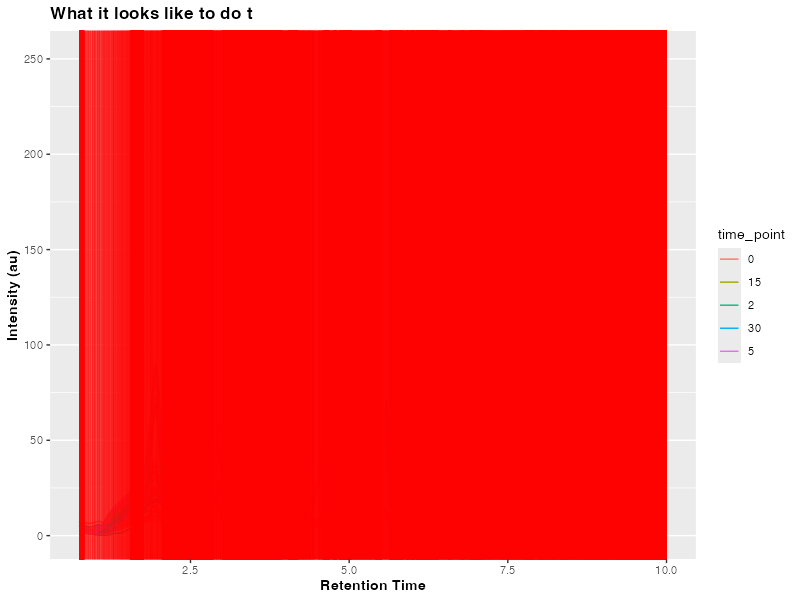

In [39]:
combinedLong |> 
    filter(instrument == "DAD") |>
    mutate(time = as.numeric(time),
      sample_id = paste(enzyme, sample, time_point, species, sep = "_")) |>
    ggplot(
      aes(
        x = time,
        y = intensity,
        color = time_point,
        group = sample_id,
    )
  ) +
  geom_line() +
  geom_vline(data = snr_3_times, aes(xintercept = time), size = 0.1, color = 'red') +
  labs(
    title = "What it looks like to do t",
    x = "Retention Time",
    y = "Intensity (au)"
  )+
  theme(
    plot.title = element_text(face = "bold"), 
    axis.title.x = element_text(face = "bold"),         
    axis.title.y = element_text(face = "bold"))

# ggplotly(Long, tooltip = "text", dynamicTicks = TRUE)


This strategy seems to be uneffective from this graph

For PCA we need to select the times where snr is greater than the selected value and replace with a small value.

In [40]:
filtered_CofV <- CofV |> mutate(intensity = if_else(snr < 3, 0.1, intensity))

In [41]:
filtered_CofV |> 
  filter(is.na(intensity))

# A tibble: 4,756 × 11
    time intensity enzyme instrument species sample time_point sample_id     mu   var   snr
   <dbl>     <dbl> <chr>  <chr>      <chr>   <chr>  <chr>      <chr>      <dbl> <dbl> <dbl>
 1  1.02        NA CYP    MS         early   m4     0          earlym40  74602.    NA    NA
 2  1.05        NA CYP    MS         early   m4     0          earlym40  71210.    NA    NA
 3  1.08        NA CYP    MS         early   m4     0          earlym40  72194.    NA    NA
 4  1.08        NA CYP    MS         early   m4     0          earlym40  71953.    NA    NA
 5  1.11        NA CYP    MS         early   m4     0          earlym40  71142.    NA    NA
 6  1.15        NA CYP    MS         early   m4     0          earlym40  71856.    NA    NA
 7  1.18        NA CYP    MS         early   m4     0          earlym40  70920.    NA    NA
 8  1.21        NA CYP    MS         early   m4     0          earlym40  70796.    NA    NA
 9  1.21        NA CYP    MS         early   m4     0    

In [42]:
pre_CofV <- long_to_wide(filtered_CofV |> select(-c(mu,var,snr))) 
pca_CofV <- pre_CofV |> 
  mutate(across(where(is.numeric), ~replace_na(., 0.1))) # Replace NA values with a small non-zero value

results <- pca(pca_CofV, center_in = FALSE, scale_in = FALSE)

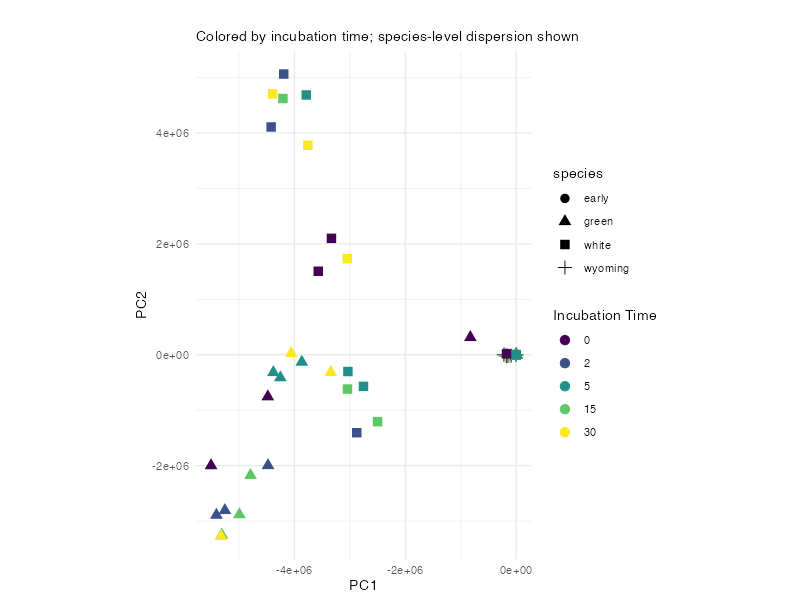

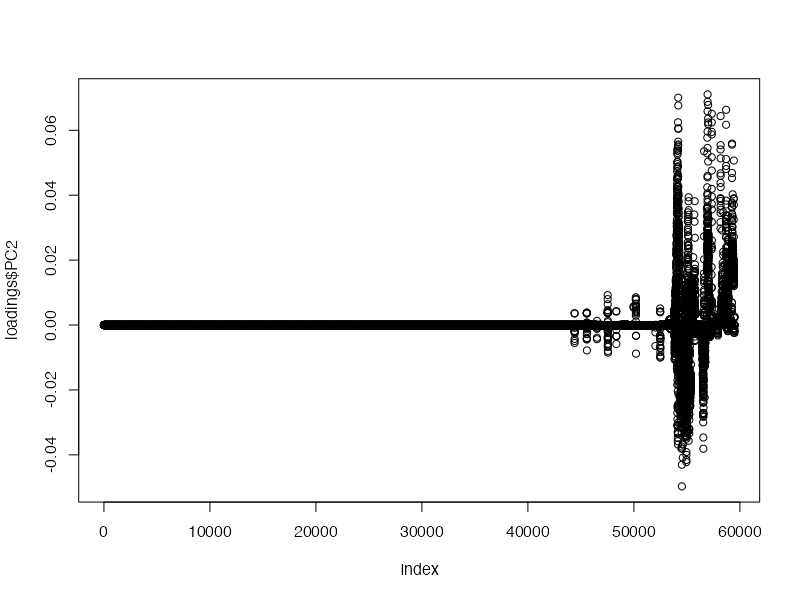

In [43]:
scores <- results$scores
plot_scores(scores, PC1, PC2)

loadings <- results$loadings
plot(loadings$PC2)

# Lets group by species, calculate SNR then filter where the max snr is below a threshold

In [44]:

snr_by_group <- combinedLong |>
  group_by(time, species) |>
  summarize(
    mu  = mean(intensity, na.rm = TRUE),
    std = sd(intensity, na.rm = TRUE),
    snr = mu / (std + 1e-6),
    .groups = "drop"
  )

low_signal_times <- snr_by_group |>
  group_by(time) |>
  summarize(max_snr = max(snr)) |>
  filter(max_snr < 5) |>
  pull(time)

low_signal_times <- low_signal_times |> 
  as.data.frame() |>       
  setNames("time") 

combined_filtered <- combinedLong |>
  filter(!(time %in% low_signal_times))

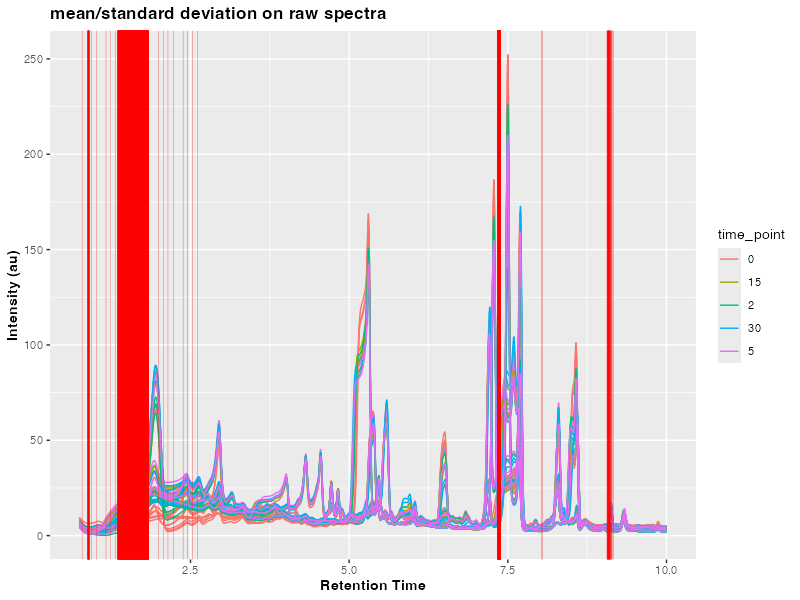

In [45]:
combined_filtered |> 
    filter(instrument == "DAD") |>
    mutate(time = as.numeric(time),
      sample_id = paste(enzyme, sample, time_point, species, sep = "_")) |>
    ggplot(
      aes(
        x = time,
        y = intensity,
        color = time_point,
        group = sample_id,
    )
  ) +
  geom_line() +
  geom_vline(data = low_signal_times, aes(xintercept = time), size = 0.1, color = 'red') +
  labs(
    title = "mean/standard deviation on raw spectra",
    x = "Retention Time",
    y = "Intensity (au)"
  )+
  theme(
    plot.title = element_text(face = "bold"), 
    axis.title.x = element_text(face = "bold"),         
    axis.title.y = element_text(face = "bold"))

# ggplotly(Long, tooltip = "text", dynamicTicks = TRUE)


Now on baseline corrected data

In [46]:
combinedFlat <- combinedWide |> correct_baseline();

flat <- wide_to_long(combinedFlat)


snr_by_group_flat <- flat |>
  group_by(time, species) |>
  summarize(
    mu  = mean(intensity, na.rm = TRUE),
    std = sd(intensity, na.rm = TRUE),
    snr = mu / (std + 1e-6),
    .groups = "drop"
  )

low_signal_times_flat <- snr_by_group_flat |>
  group_by(time) |>
  summarize(max_snr = max(snr)) |>
  filter(max_snr < 5) |>
  pull(time) 

low_signal_times_flat <- low_signal_times_flat |> 
  as.data.frame() |>       
  setNames("time") |> 
  mutate(time = as.numeric(time))

combined_filtered_flat <- flat |>
  filter(!(time %in% low_signal_times_flat)) |> 
  mutate(time = as.numeric(time))

Warning messages:
1: In asysm(x, ...) : Function asysm did not reach convergence
2: In asysm(x, ...) : Function asysm did not reach convergence
3: In asysm(x, ...) : Function asysm did not reach convergence
4: In asysm(x, ...) : Function asysm did not reach convergence


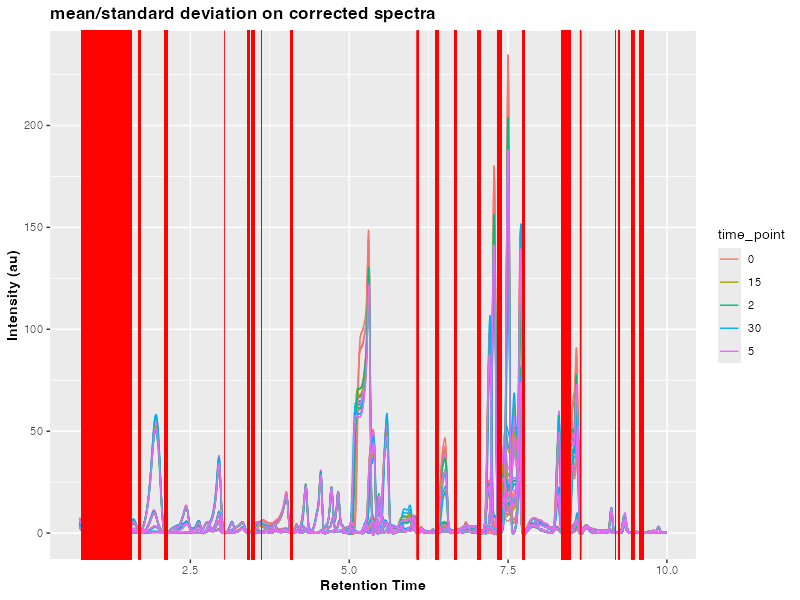

In [47]:
combined_filtered_flat |> 
    filter(instrument == "DAD") |>
    mutate(time = as.numeric(time),
      sample_id = paste(enzyme, sample, time_point, species, sep = "_")) |>
    ggplot(
      aes(
        x = time,
        y = intensity,
        color = time_point,
        group = sample_id,
    )
  ) +
  geom_line() +
  geom_vline(data = low_signal_times_flat, aes(xintercept = time), size = 0.1, color = 'red') +
  labs(
    title = "mean/standard deviation on corrected spectra",
    x = "Retention Time",
    y = "Intensity (au)"
  )+
  theme(
    plot.title = element_text(face = "bold"), 
    axis.title.x = element_text(face = "bold"),         
    axis.title.y = element_text(face = "bold"))

# ggplotly(Long, tooltip = "text", dynamicTicks = TRUE)


The regions on retention time look much better after baseline correction. The rest of the stats will be on baseline corrected data.

# Max of Bin for all species divided by Standard Deviation

In [48]:
Dataframe <- combinedWide |> correct_baseline();

Warning messages:
1: In asysm(x, ...) : Function asysm did not reach convergence
2: In asysm(x, ...) : Function asysm did not reach convergence
3: In asysm(x, ...) : Function asysm did not reach convergence
4: In asysm(x, ...) : Function asysm did not reach convergence


In [49]:
Dataframe_Long <- wide_to_long(Dataframe)

Dataframe_snr_stat <- Dataframe_Long |>
  group_by(time) |>
  mutate(
    bin_max = max(intensity, na.rm = TRUE),
    std = sd(intensity, na.rm = TRUE),
    snr = bin_max / std
  ) |>
  ungroup()

times_below_snr <- Dataframe_snr_stat |>
  group_by(time) |>
  summarize(max_snr = max(snr)) |>
  filter(max_snr < 3) |>
  pull(time) 

times_below_snr_num <- times_below_snr |> 
  as.data.frame() |>       
  setNames("time") |> 
  mutate(time = as.numeric(time))

Dataframe_filtered <- Dataframe_snr_stat |>
  filter(!(time %in% times_below_snr_num)) |> 
  mutate(time = as.numeric(time))

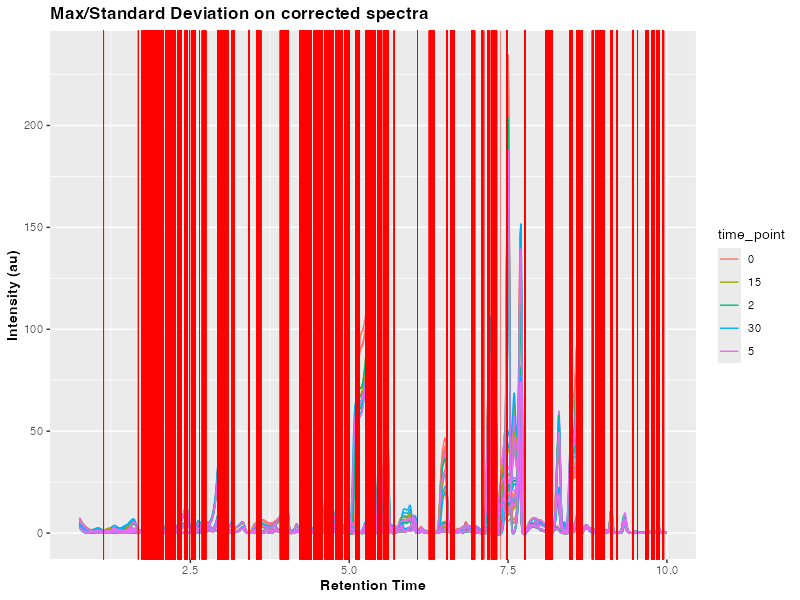

In [50]:
Dataframe_filtered |> 
    filter(instrument == "DAD") |>
    mutate(time = as.numeric(time),
      sample_id = paste(enzyme, sample, time_point, species, sep = "_")) |>
    ggplot(
      aes(
        x = time,
        y = intensity,
        color = time_point,
        group = sample_id,
    )
  ) +
  geom_line() +
  geom_vline(data = times_below_snr_num, aes(xintercept = time), size = 0.1, color = 'red') +
  labs(
    title = "Max/Standard Deviation on corrected spectra",
    x = "Retention Time",
    y = "Intensity (au)"
  )+
  theme(
    plot.title = element_text(face = "bold"), 
    axis.title.x = element_text(face = "bold"),         
    axis.title.y = element_text(face = "bold"))

# ggplotly(Long, tooltip = "text", dynamicTicks = TRUE)


This looks very similar to the mean/std technique, lets do pca

In [51]:
Dataframe_pre <- Dataframe_filtered |>
  mutate(intensity = if_else(time %in% times_below_snr_num,
                             0,
                             intensity))

pre_CofV <- long_to_wide(Dataframe_pre |> select(-c(bin_max,snr))) 
pca_CofV <- pre_CofV |> 
  mutate(across(where(is.numeric), ~replace_na(., 0.1))) # Replace NA values with a small non-zero value

results <- pca(pca_CofV, center_in = TRUE, scale_in = TRUE)

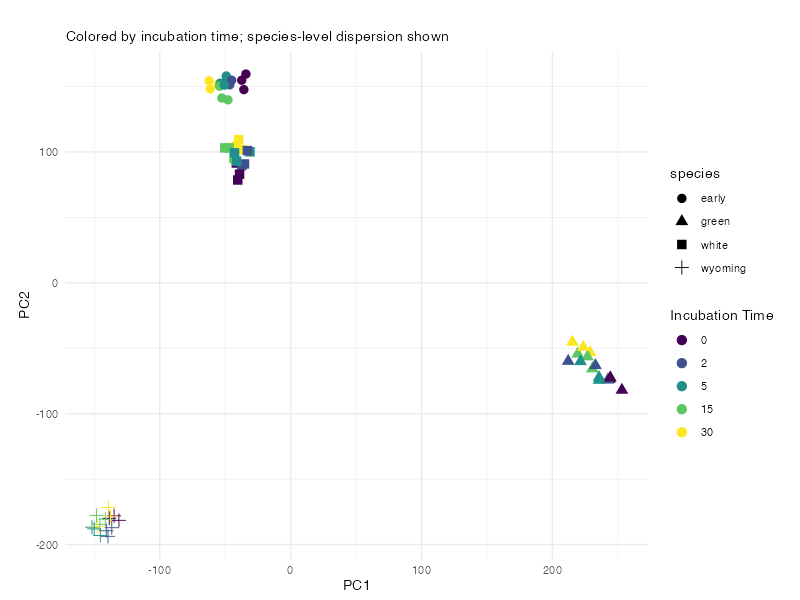

In [52]:
scores <- results$scores
plot_scores(scores, PC1, PC2)

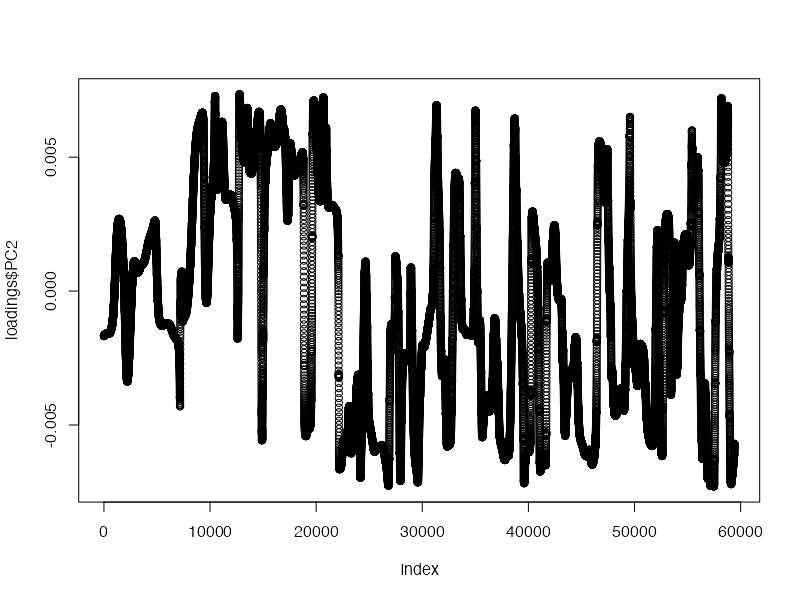

In [53]:
loadings <- results$loadings
plot(loadings$PC2)

# Lastly, max of bin and then divide by the range 

In [54]:
Dataframe_snr_stat <- Dataframe_Long |>
  group_by(time) |>
  mutate(
    bin_max = max(intensity, na.rm = TRUE),
    range = bin_max - min(intensity, na.rm = TRUE),
    snr = bin_max / range
  ) |>
  ungroup()

times_below_snr <- Dataframe_snr_stat |>
  group_by(time) |>
  summarize(max_snr = max(snr)) |>
  filter(max_snr < 5) |>
  pull(time) 

times_below_snr_num <- times_below_snr |> 
  as.data.frame() |>       
  setNames("time") |> 
  mutate(time = as.numeric(time))

Dataframe_filtered <- Dataframe_snr_stat |>
  filter(!(time %in% times_below_snr_num)) |> 
  mutate(time = as.numeric(time))

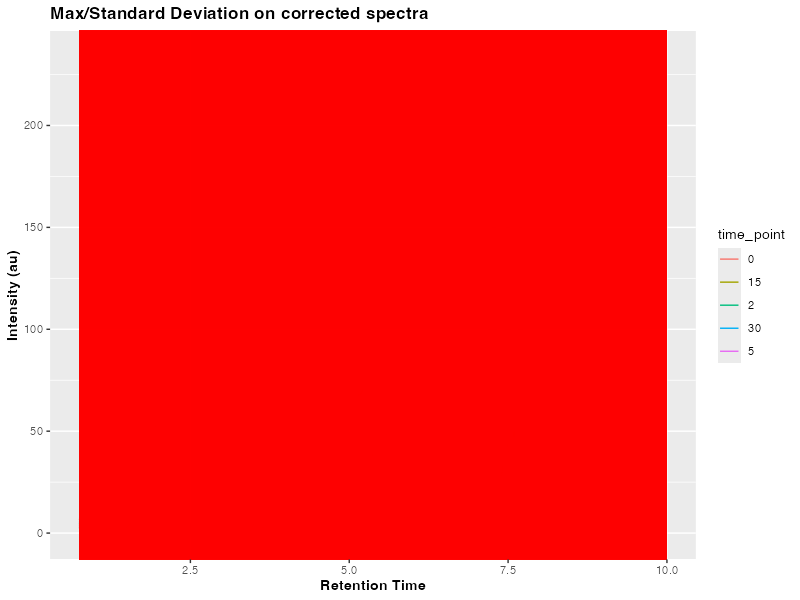

In [55]:
Dataframe_filtered |> 
    filter(instrument == "DAD") |>
    mutate(time = as.numeric(time),
      sample_id = paste(enzyme, sample, time_point, species, sep = "_")) |>
    ggplot(
      aes(
        x = time,
        y = intensity,
        color = time_point,
        group = sample_id,
    )
  ) +
  geom_line() +
  geom_vline(data = times_below_snr_num, aes(xintercept = time), size = 0.1, color = 'red') +
  labs(
    title = "Max/Standard Deviation on corrected spectra",
    x = "Retention Time",
    y = "Intensity (au)"
  )+
  theme(
    plot.title = element_text(face = "bold"), 
    axis.title.x = element_text(face = "bold"),         
    axis.title.y = element_text(face = "bold"))

# ggplotly(Long, tooltip = "text", dynamicTicks = TRUE)


In [56]:
# Dataframe_pre |> 
#   filter(is.na(intensity))

pre_CofV <- long_to_wide(Dataframe_filtered |> select(-c(bin_max,snr))) 
pca_CofV <- pre_CofV |> 
  mutate(across(where(is.numeric), ~replace_na(., 0.1))) # Replace NA values with a small non-zero value

results <- pca(pca_CofV, center_in = TRUE, scale_in = TRUE)

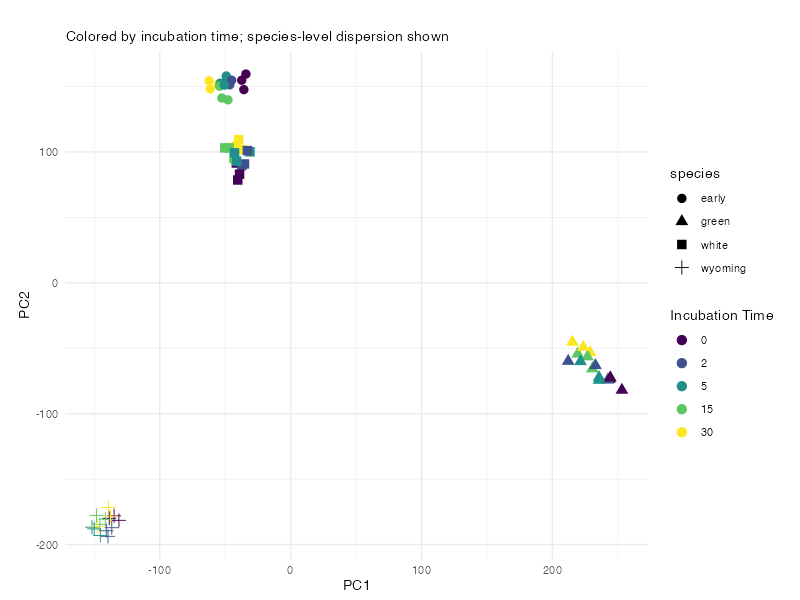

In [57]:
scores <- results$scores
plot_scores(scores, PC1, PC2)

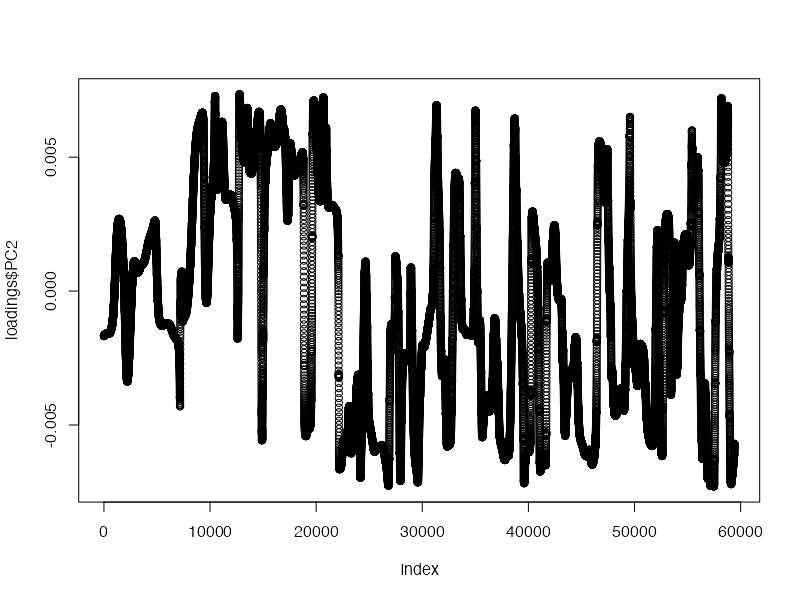

In [58]:
loadings <- results$loadings
plot(loadings$PC2)